# Alzheimer's Disease Brain MRI Segmentation
## SegNet | OASIS disc1 + disc2
Full pipeline: data loading → preprocessing → model training → metrics → visualizations

**Note:** EarlyStopping disabled — model trains for the full configured epochs as instructed.

**Architecture note:** Unlike the VGG-UNet variants, SegNet does NOT use skip connections. Instead it remembers the exact **max-pooling indices** from the encoder and reuses them during decoder upsampling ("unpooling"). This makes it memory-efficient and a useful architectural contrast point in your benchmark — no feature concatenation, just index-based spatial recall.

## 1. Import Libraries

In [1]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Dropout, Activation, Layer
)
from tensorflow.keras.models import Model
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

2026-06-21 12:28:48.215875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782044928.392137      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782044928.443912      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782044928.858687      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782044928.858730      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782044928.858732      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [2]:
# ─── Paths ────────────────────────────────────────────────────────────────────
ROOTS = [
    '/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1',
    '/kaggle/input/datasets/maheswarimudadla/disc2-oasis11/disc2',
]

PROCESSED_DIR   = 'oasis_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15

print('Config set ✓')

Config set ✓


## 3. Load & Preprocess OASIS Data (disc1 + disc2)
OASIS stores brain volumes as Analyze `.img/.hdr` pairs. We slice along the coronal axis and save each 2-D slice as a PNG.

In [3]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')

Directories ready ✓


In [4]:
def normalize_slice(arr):
    """Min-max normalise a 2-D array to [0, 255] uint8."""
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices(subject_dir, img_out, mask_out, step=2):
    """
    For one OASIS subject directory, find the T88 masked brain volume
    and the FSL_SEG tissue mask, then save every `step`-th coronal slice.
    Returns number of slices saved.
    """
    subject_name = os.path.basename(subject_dir)
    t88_dir = os.path.join(subject_dir, 'PROCESSED', 'MPRAGE', 'T88_111')
    fsl_dir = os.path.join(subject_dir, 'FSL_SEG')

    if not os.path.isdir(t88_dir) or not os.path.isdir(fsl_dir):
        return 0

    brain_img_path = None
    for f in os.listdir(t88_dir):
        if f.endswith('masked_gfc.img'):
            brain_img_path = os.path.join(t88_dir, f)
            break

    seg_img_path = None
    for f in os.listdir(fsl_dir):
        if f.endswith('fseg.img'):
            seg_img_path = os.path.join(fsl_dir, f)
            break

    if brain_img_path is None or seg_img_path is None:
        return 0

    brain_vol = np.squeeze(nib.load(brain_img_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_img_path).get_fdata())

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = (seg_sl > 0).astype(np.uint8) * 255

        fname = f"{subject_name}_sl{i:03d}.png"
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved


# ─── Clear old slices (fresh run) ──────────────────────────────────────────────
for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# ─── Gather subjects from both discs ───────────────────────────────────────────
subject_dirs = []
for root in ROOTS:
    if os.path.exists(root):
        dirs = [
            os.path.join(root, d)
            for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and d.startswith('OAS')
        ]
        subject_dirs += dirs
        print(f'{root} → {len(dirs)} subjects')

print(f'\nTotal subjects: {len(subject_dirs)}')

# ─── Extract ────────────────────────────────────────────────────────────────────
total_slices = 0
for subj in tqdm(subject_dirs, desc='Extracting slices'):
    total_slices += extract_slices(subj, IMAGE_FOLDER, MASK_FOLDER)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')

/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1 → 39 subjects
/kaggle/input/datasets/maheswarimudadla/disc2-oasis11/disc2 → 38 subjects

Total subjects: 77


Extracting slices:   0%|          | 0/77 [00:00<?, ?it/s]


Total slices extracted : 6622
Images saved           : 6622
Masks  saved           : 6622


## 4. Data Visualisation

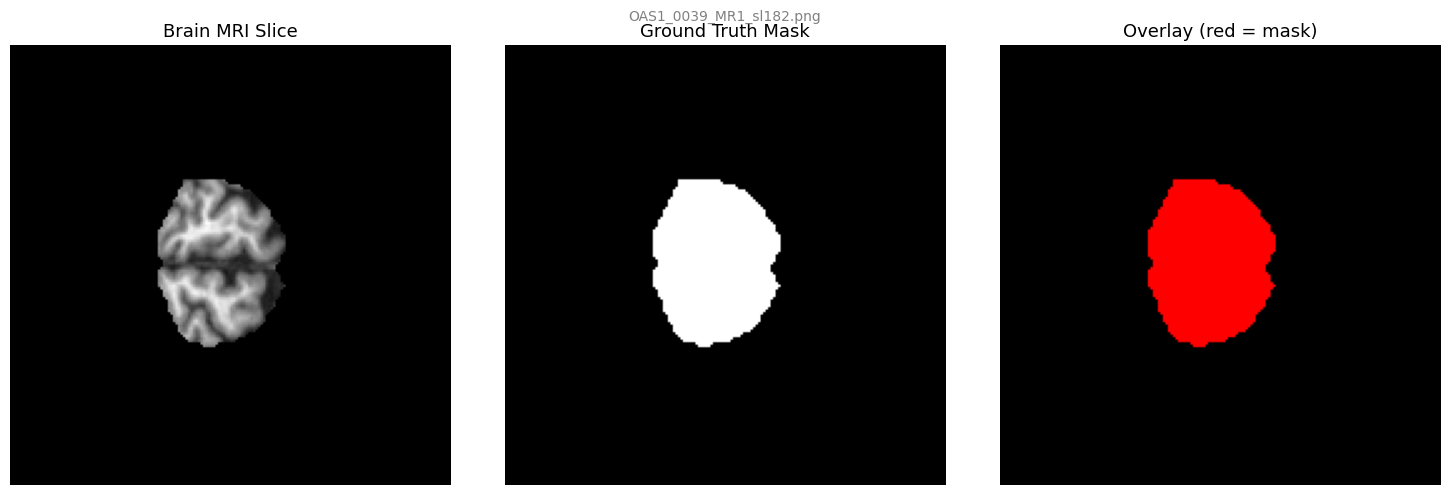

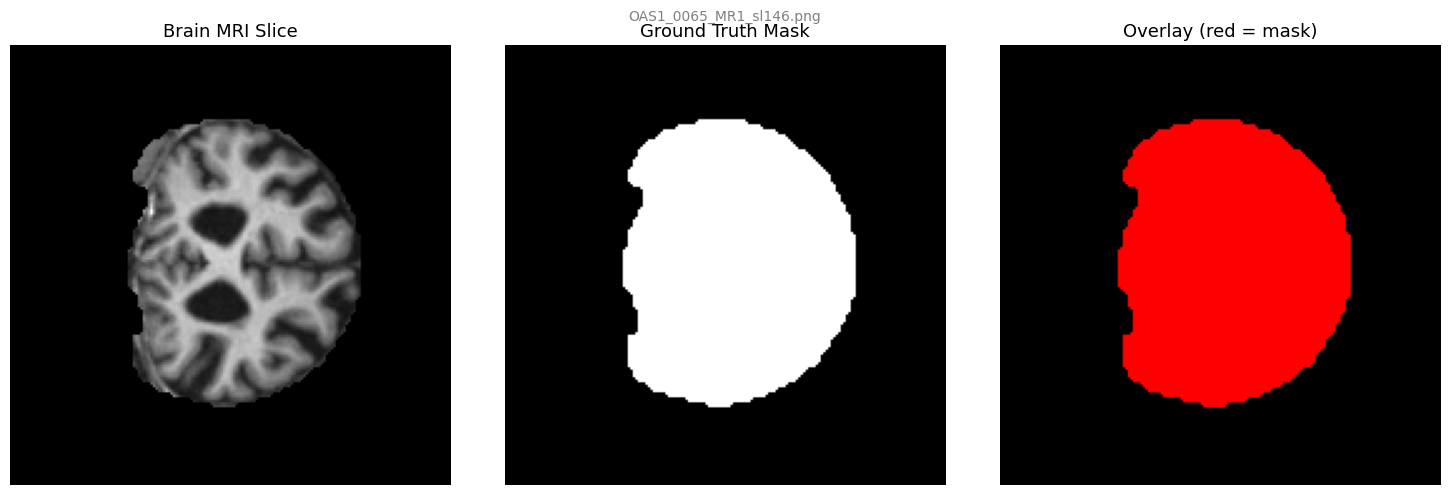

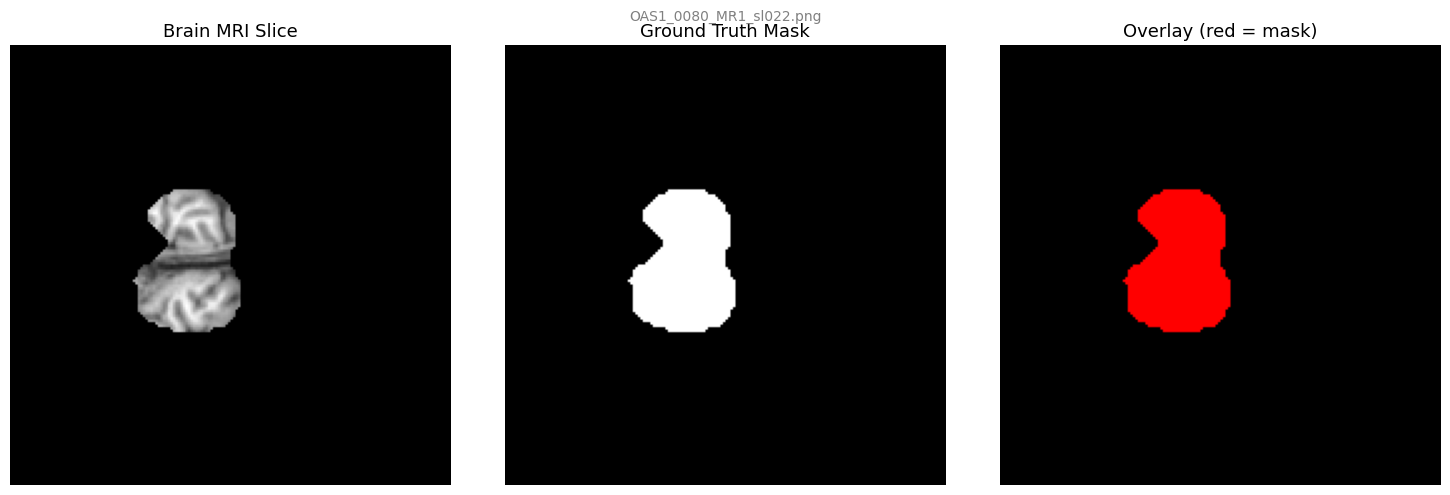

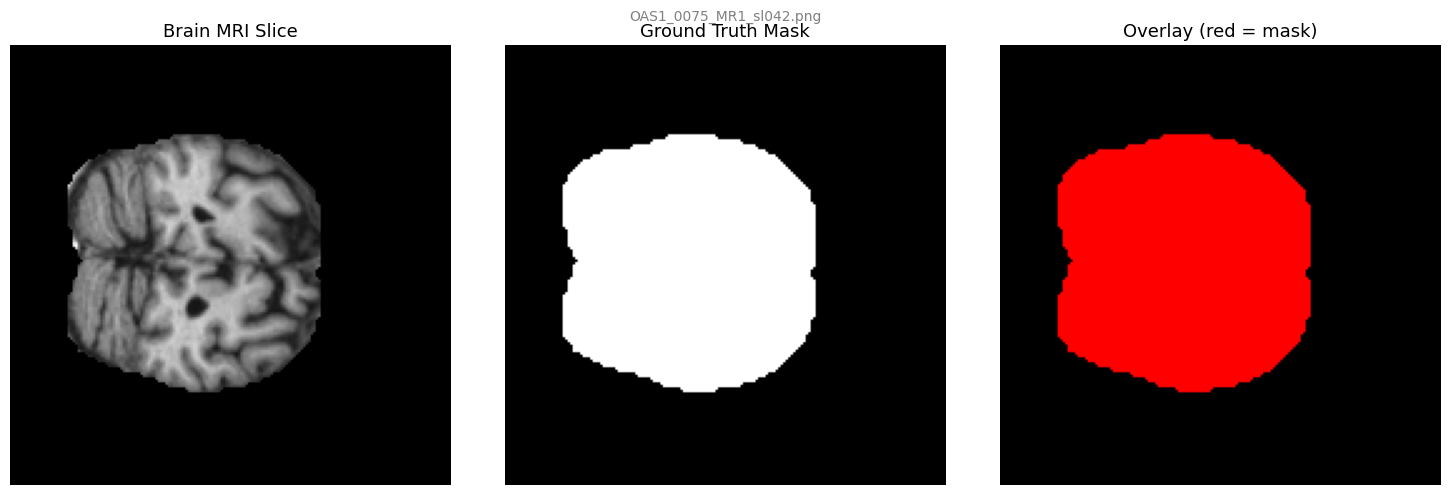

In [5]:
def visualize_sample(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[mask > 127, 0] = 255
    overlay[mask > 127, 1] = 0
    overlay[mask > 127, 2] = 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img,     cmap='gray');  axes[0].set_title('Brain MRI Slice',      fontsize=13)
    axes[1].imshow(mask,    cmap='gray');  axes[1].set_title('Ground Truth Mask',    fontsize=13)
    axes[2].imshow(overlay);               axes[2].set_title('Overlay (red = mask)', fontsize=13)
    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [6]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch! Check filenames.'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 5628  |  Test: 994


  0%|          | 0/5628 [00:00<?, ?it/s]

  0%|          | 0/994 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline

In [7]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1782044973.544689      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 1)


## 7. Model — SegNet (encoder-decoder with max-pooling index unpooling)
**How SegNet differs from the VGG-UNet family:**
- **No skip connections / feature concatenation.** Standard UNet copies encoder feature maps directly into the decoder. SegNet instead only remembers *where* the max value was during each MaxPooling step (the pooling indices) and places values back at exactly those positions during upsampling ("unpooling"). Everywhere else is filled with zeros, then convolutions smooth/refine it.
- **Much smaller memory footprint** at inference — UNet stores full encoder feature maps for every skip; SegNet only stores small index tensors.
- **Tends to give blurrier boundaries** than UNet since unpooling loses more spatial detail than direct feature concatenation — a useful comparison point for your benchmark.
- Built from scratch here (5 conv blocks, VGG-style channel widths) rather than wrapping a pretrained VGG16/19, since Keras has no native `MaxPoolingWithArgmax`/`MaxUnpooling` layer — we implement them manually below using `tf.nn.max_pool_with_argmax`.

In [8]:
class MaxPoolingWithIndices(Layer):
    """2x2 max-pool that also returns the flat argmax indices, needed for SegNet's unpooling."""
    def call(self, x):
        pooled, indices = tf.nn.max_pool_with_argmax(
            x, ksize=2, strides=2, padding='SAME', include_batch_in_index=True
        )
        return pooled, indices


class MaxUnpooling(Layer):
    """Scatters values back to their original pre-pooling positions using stored indices.
    IMPORTANT: the channel count `c` passed here must match the number of channels
    in `x` at call time (i.e. unpool BEFORE changing channel depth with a conv)."""
    def __init__(self, h, w, c, **kwargs):
        super().__init__(**kwargs)
        self.h = h
        self.w = w
        self.c = c

    def call(self, inputs):
        x, indices = inputs
        batch_size = tf.shape(x)[0]
        flat_x = tf.reshape(x, [-1])
        flat_indices = tf.reshape(indices, [-1, 1])
        flat_output_size = batch_size * self.h * self.w * self.c
        flat_output = tf.scatter_nd(flat_indices, flat_x, [flat_output_size])
        return tf.reshape(flat_output, [batch_size, self.h, self.w, self.c])

    def get_config(self):
        config = super().get_config()
        config.update({'h': self.h, 'w': self.w, 'c': self.c})
        return config


def conv_bn_relu(x, filters, name_prefix, n=1):
    """One or more Conv2D + BN + ReLU layers (VGG-style block)."""
    for i in range(n):
        x = Conv2D(filters, (3, 3), padding='same', name=f'{name_prefix}_c{i+1}')(x)
        x = BatchNormalization(name=f'{name_prefix}_bn{i+1}')(x)
        x = Activation('relu', name=f'{name_prefix}_act{i+1}')(x)
    return x


def build_segnet(input_shape=(224, 224, 3)):
    """
    Classic SegNet — VGG16-style conv blocks, built from scratch (no pretrained weights),
    paired with index-based unpooling instead of skip connections.

    Key fix: each MaxPoolingWithIndices is applied on a tensor with channel count C.
    The matching MaxUnpooling later must receive a tensor that STILL has C channels
    at that point — so we unpool first, THEN run the conv block that changes channels.
    """
    inputs = Input(shape=input_shape, name='input')
    pool_layer = MaxPoolingWithIndices()

    # ── Encoder ────────────────────────────────────────────────────────────────
    e1 = conv_bn_relu(inputs, 64,  'enc1', n=2)
    h1, w1, c1 = e1.shape[1], e1.shape[2], e1.shape[3]          # c1 = 64
    p1, idx1 = pool_layer(e1)                                   # 112x112, 64ch

    e2 = conv_bn_relu(p1, 128, 'enc2', n=2)
    h2, w2, c2 = e2.shape[1], e2.shape[2], e2.shape[3]          # c2 = 128
    p2, idx2 = pool_layer(e2)                                   # 56x56, 128ch

    e3 = conv_bn_relu(p2, 256, 'enc3', n=3)
    h3, w3, c3 = e3.shape[1], e3.shape[2], e3.shape[3]          # c3 = 256
    p3, idx3 = pool_layer(e3)                                   # 28x28, 256ch

    e4 = conv_bn_relu(p3, 512, 'enc4', n=3)
    h4, w4, c4 = e4.shape[1], e4.shape[2], e4.shape[3]          # c4 = 512
    p4, idx4 = pool_layer(e4)                                   # 14x14, 512ch

    e5 = conv_bn_relu(p4, 512, 'enc5', n=3)
    h5, w5, c5 = e5.shape[1], e5.shape[2], e5.shape[3]          # c5 = 512
    p5, idx5 = pool_layer(e5)                                   # 7x7, 512ch (bottleneck)

    x = Dropout(0.3, name='bottleneck_drop')(p5)                # still 512ch — matches idx5's c5=512 ✓

    # ── Decoder — unpool FIRST (channel count must match the paired index's),
    #              THEN apply conv block which may change channel depth ─────────
    d5 = MaxUnpooling(h5, w5, c5, name='unpool5')([x, idx5])     # x is 512ch, idx5 is 512ch ✓
    d5 = conv_bn_relu(d5, 512, 'dec5', n=3)                      # stays 512ch

    d4 = MaxUnpooling(h4, w4, c4, name='unpool4')([d5, idx4])    # d5 is 512ch, idx4 is 512ch ✓
    d4 = conv_bn_relu(d4, 256, 'dec4', n=3)                      # now drops to 256ch (prep for next unpool)

    d3 = MaxUnpooling(h3, w3, c3, name='unpool3')([d4, idx3])    # d4 is 256ch, idx3 is 256ch ✓\n",
    d3 = conv_bn_relu(d3, 128, 'dec3', n=3)                      # now drops to 128ch\n",
    d2 = MaxUnpooling(h2, w2, c2, name='unpool2')([d3, idx2])    # d3 is 128ch, idx2 is 128ch ✓\n",
    d2 = conv_bn_relu(d2, 64, 'dec2', n=2)                       # now drops to 64ch\n",
    d1 = MaxUnpooling(h1, w1, c1, name='unpool1')([d2, idx1])    # d2 is 64ch, idx1 is 64ch ✓\n",
    d1 = conv_bn_relu(d1, 64,  'dec1', n=2)                      # stays 64ch\n",

    # ── Output ──────────────────────────────────────────────────────────────
    output = Conv2D(1, (1, 1), activation='sigmoid', name='output')(d1)

    model = Model(inputs=inputs, outputs=output, name='SegNet')
    return model


model = build_segnet(input_shape=(*IMG_SIZE, 3))
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

Model built ✓
Total parameters      : 24,957,697
Trainable parameters  : 24,943,361


## 8. Custom Metrics & Loss

In [9]:
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1.0):
    """Intersection over Union (Jaccard Index)"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def precision_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_pred_f) + K.epsilon())


def recall_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_true_f) + K.epsilon())


def pixel_accuracy(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(K.round(K.clip(y_true_f * y_pred_f, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true_f) * (1 - y_pred_f), 0, 1)))
    total = K.cast(tf.size(y_true_f), K.floatx())
    return (tp + tn) / total


def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.keras.losses.binary_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, precision_smooth, recall_smooth, pixel_accuracy]
)

print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [10]:
# Disable XLA JIT — MaxPoolWithArgmax has no XLA kernel on this GPU/TF version
import tensorflow as tf
tf.config.optimizer.set_jit(False)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, precision_smooth, recall_smooth, pixel_accuracy],
    jit_compile=False   # <-- disables XLA for this model specifically
)

In [12]:
model.summary()

# Note: tf.keras.utils.plot_model can fail on models with custom Layer subclasses
# that return multiple outputs (MaxPoolingWithIndices) — wrapped in try/except.
try:
    tf.keras.utils.plot_model(
        model,
        to_file='segnet_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=60
    )
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped (custom layer types):', e)

Model: "SegNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c1 (Conv2D)    │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 224, 224,  │        256 │ enc1_c1[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act1           │ (None, 224, 224,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c2 (Conv2D)    │ (None, 224, 224,  │     36,928 │ enc1_act1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 224, 224,  │        256 │ enc1_c2[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act2           │ (None, 224, 224,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling_with_i… │ [(None, 7, 7,     │          0 │ enc1_act2[0][0],  │
│ (MaxPoolingWithInd… │ 512), (None, 7,   │            │ enc2_act2[0][0],  │
│                     │ 7, 512)]          │            │ enc3_act3[0][0],  │
│                     │                   │            │ enc4_act3[0][0],  │
│                     │                   │            │ enc5_act3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c1 (Conv2D)    │ (None, 112, 112,  │     73,856 │ max_pooling_with… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 112, 112,  │        512 │ enc2_c1[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_act1           │ (None, 112, 112,  │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c2 (Conv2D)    │ (None, 112, 112,  │    147,584 │ enc2_act1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 112, 112,  │        512 │ enc2_c2[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_act2           │ (None, 112, 112,  │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c1 (Conv2D)    │ (None, 56, 56,    │    295,168 │ max_pooling_with… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 56, 56,    │      1,024 │ enc3_c1[0][0]   

 Total params: 24,957,697 (95.21 MB)

 Trainable params: 24,943,361 (95.15 MB)

 Non-trainable params: 14,336 (56.00 KB)

Architecture diagram saved ✓


## 10. Callbacks  (EarlyStopping disabled — full epochs as instructed)

In [13]:
def create_mask(pred):
    return tf.math.round(pred)


def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            pred_mask = create_mask(preds[i])
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(masks[i].numpy()[..., 0], cmap='gray'); axes[1].set_title('Ground Truth')
            axes[2].imshow(pred_mask.numpy()[..., 0], cmap='gray'); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()


class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')


logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_segnet.keras', verbose=1, save_best_only=True,
                               monitor='val_iou_score', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                 min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed — train for the full EPOCHS as instructed
]

print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1782044977.759763     141 cuda_dnn.cc:529] Loaded cuDNN version 91002


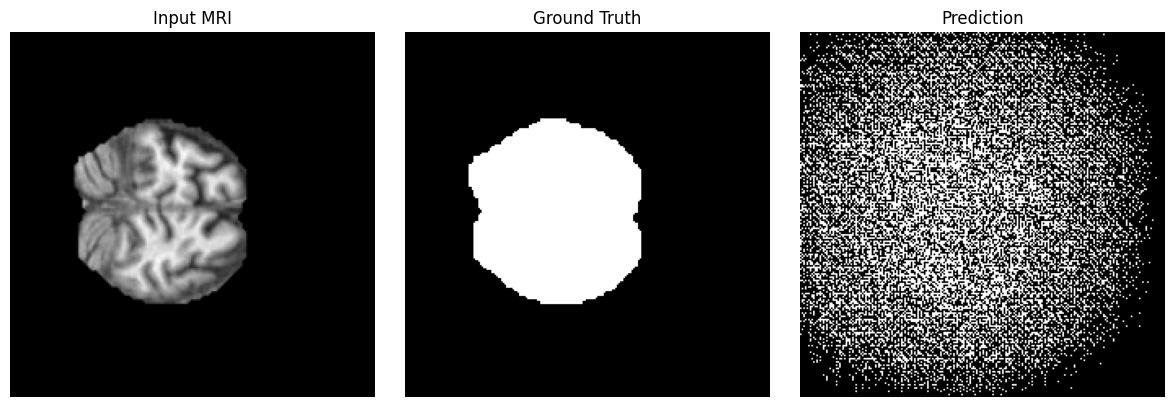

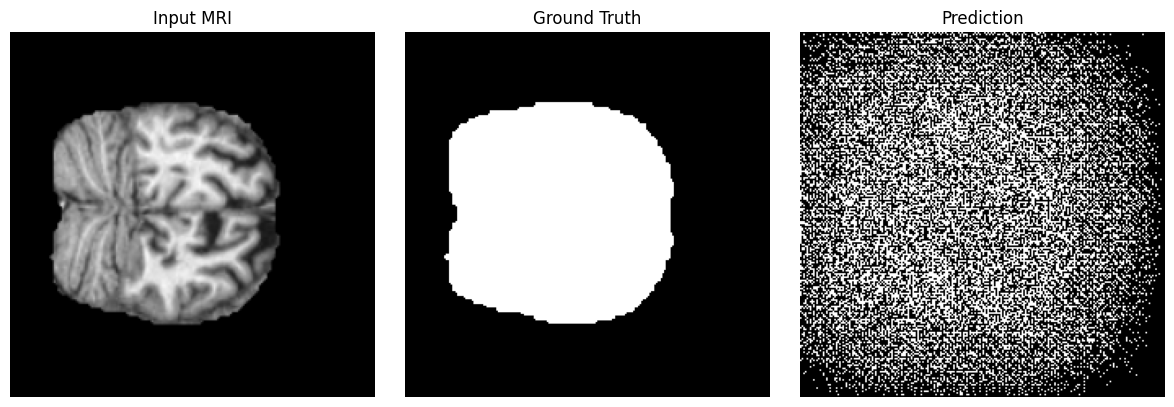

In [14]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 351
Validation steps : 62
Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - dice_coefficient: 0.7631 - iou_score: 0.6493 - loss: 0.4412 - pixel_accuracy: 0.9396 - precision_smooth: 0.6927 - recall_smooth: 0.9052
Epoch 1: val_iou_score improved from None to 0.84725, saving model to best_model_segnet.keras

Epoch 1: finished saving model to best_model_segnet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 433ms/step - dice_coefficient: 0.8406 - iou_score: 0.7502 - loss: 0.2721 - pixel_accuracy: 0.9770 - precision_smooth: 0.7771 - recall_smooth: 0.9565 - val_dice_coefficient: 0.9171 - val_iou_score: 0.8472 - val_loss: 0.1552 - val_pixel_accuracy: 0.9805 - val_precision_smooth: 0.8978 - val_recall_smooth: 0.9376 - learning_rate: 1.0000e-04
Epoch 2/100
  1/351 ━━━━━━━━━━━━━━━━━━━━ 24:30 4s/step - dice_coefficient: 0.7147 - iou_score: 0.5560 - loss: 0.3897 - pixel_accuracy: 0.9953 - precision_smooth: 0.5608 - recall_smooth: 0.9849
Epoch 2: val_iou_score improved from 0.8472

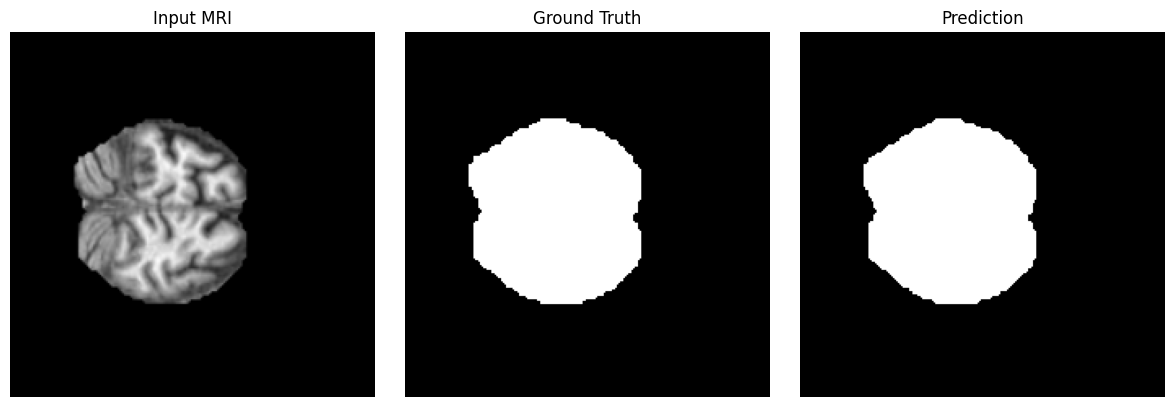

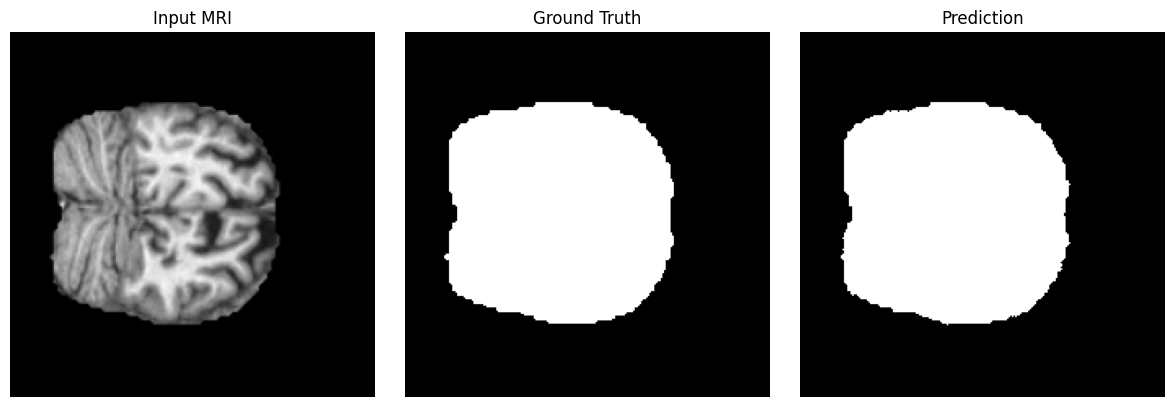

Prediction after epoch 10


Epoch 10: val_iou_score improved from 0.98328 to 0.98342, saving model to best_model_segnet.keras

Epoch 10: finished saving model to best_model_segnet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - dice_coefficient: 0.9251 - iou_score: 0.8606 - loss: 0.0961 - pixel_accuracy: 0.9986 - precision_smooth: 0.8665 - recall_smooth: 0.9921 - val_dice_coefficient: 0.9916 - val_iou_score: 0.9834 - val_loss: 0.0151 - val_pixel_accuracy: 0.9985 - val_precision_smooth: 0.9866 - val_recall_smooth: 0.9967 - learning_rate: 1.0000e-04
Epoch 11/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - dice_coefficient: 0.9783 - iou_score: 0.9591 - loss: 0.0332 - pixel_accuracy: 0.9979 - precision_smooth: 0.9642 - recall_smooth: 0.9945
Epoch 11: val_iou_score did not improve from 0.98342
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 425ms/step - dice_coefficient: 0.9746 - iou_score: 0.9527 - loss: 0.0437 - pixel_accuracy: 0.9959 - precision_smooth: 0.9610 - recall_smooth: 0.9911 - val_dice_co

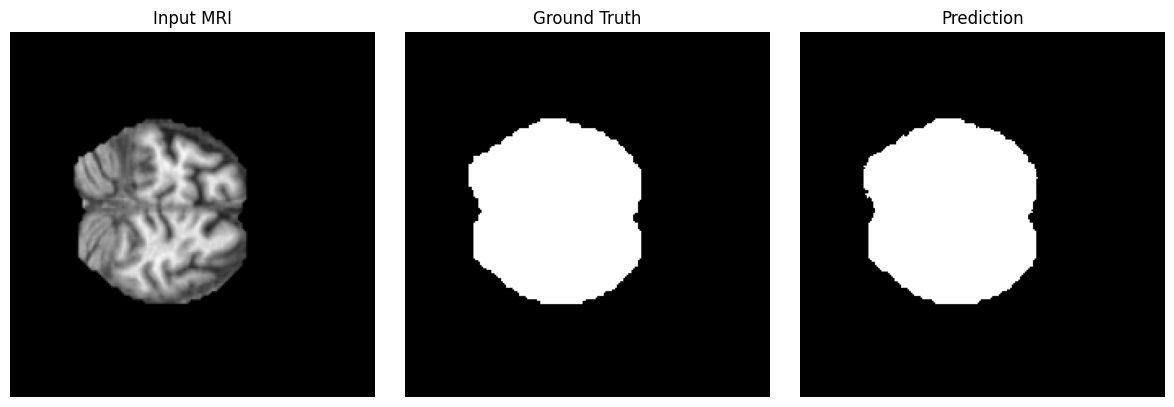

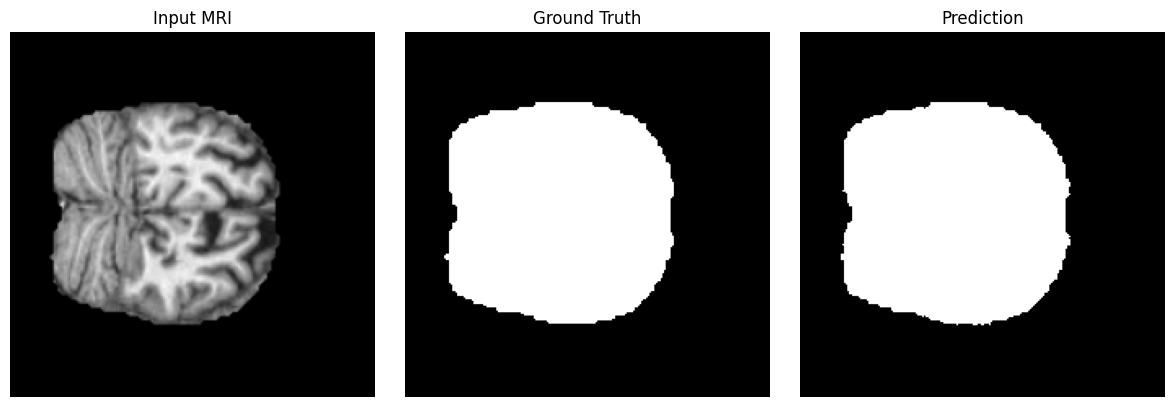

Prediction after epoch 20


Epoch 20: val_iou_score improved from 0.99057 to 0.99058, saving model to best_model_segnet.keras

Epoch 20: finished saving model to best_model_segnet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - dice_coefficient: 0.9786 - iou_score: 0.9582 - loss: 0.0278 - pixel_accuracy: 0.9991 - precision_smooth: 0.9621 - recall_smooth: 0.9958 - val_dice_coefficient: 0.9953 - val_iou_score: 0.9906 - val_loss: 0.0103 - val_pixel_accuracy: 0.9981 - val_precision_smooth: 0.9917 - val_recall_smooth: 0.9989 - learning_rate: 1.0000e-04
Epoch 21/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - dice_coefficient: 0.9931 - iou_score: 0.9864 - loss: 0.0113 - pixel_accuracy: 0.9988 - precision_smooth: 0.9894 - recall_smooth: 0.9969
Epoch 21: val_iou_score improved from 0.99058 to 0.99165, saving model to best_model_segnet.keras

Epoch 21: finished saving model to best_model_segnet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 151s 429ms/step - dice_coefficient: 0.9932 - iou_score: 0.9866

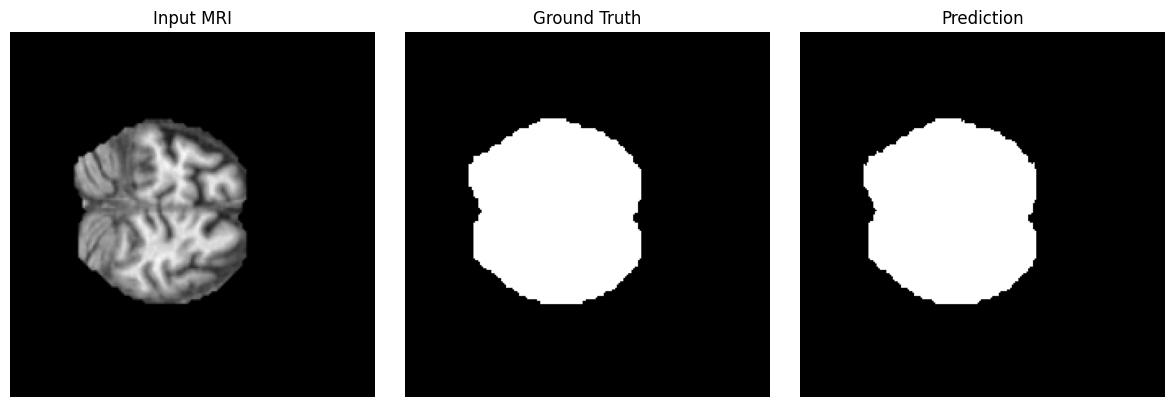

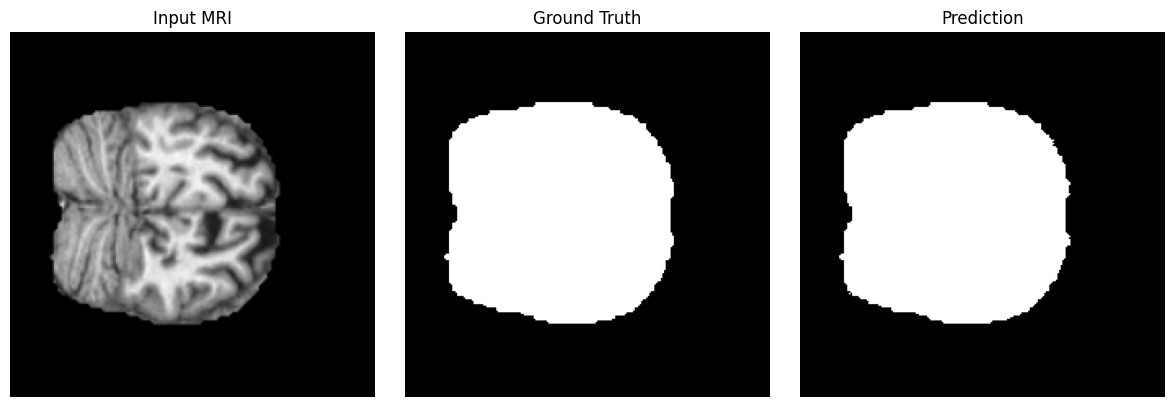

Prediction after epoch 30


Epoch 30: val_iou_score did not improve from 0.99508
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - dice_coefficient: 0.9924 - iou_score: 0.9848 - loss: 0.0101 - pixel_accuracy: 0.9996 - precision_smooth: 0.9872 - recall_smooth: 0.9976 - val_dice_coefficient: 0.9974 - val_iou_score: 0.9948 - val_loss: 0.0059 - val_pixel_accuracy: 0.9988 - val_precision_smooth: 0.9953 - val_recall_smooth: 0.9995 - learning_rate: 1.0000e-04
Epoch 31/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - dice_coefficient: 0.9972 - iou_score: 0.9944 - loss: 0.0048 - pixel_accuracy: 0.9994 - precision_smooth: 0.9960 - recall_smooth: 0.9984
Epoch 31: val_iou_score improved from 0.99508 to 0.99589, saving model to best_model_segnet.keras

Epoch 31: finished saving model to best_model_segnet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 151s 430ms/step - dice_coefficient: 0.9972 - iou_score: 0.9944 - loss: 0.0048 - pixel_accuracy: 0.9994 - precision_smooth: 0.9960 - recall_smooth: 0.9984 - val_dice_co

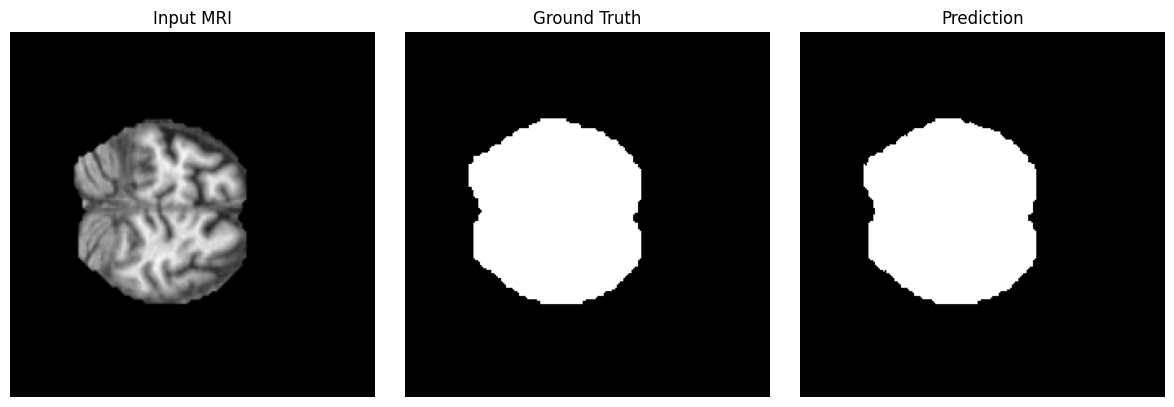

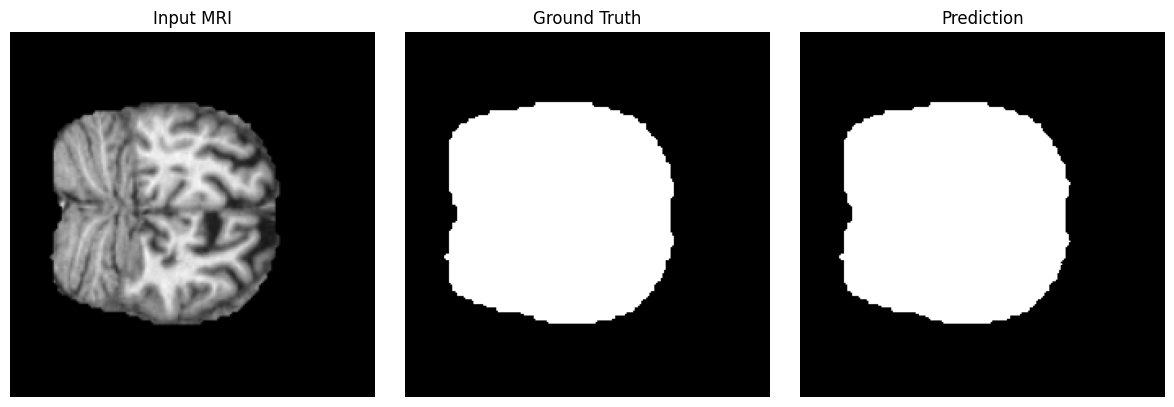

Prediction after epoch 40


Epoch 40: val_iou_score did not improve from 0.99653
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - dice_coefficient: 0.9964 - iou_score: 0.9929 - loss: 0.0048 - pixel_accuracy: 0.9998 - precision_smooth: 0.9941 - recall_smooth: 0.9987 - val_dice_coefficient: 0.9982 - val_iou_score: 0.9964 - val_loss: 0.0043 - val_pixel_accuracy: 0.9991 - val_precision_smooth: 0.9966 - val_recall_smooth: 0.9998 - learning_rate: 5.0000e-05
Epoch 41/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - dice_coefficient: 0.9987 - iou_score: 0.9974 - loss: 0.0023 - pixel_accuracy: 0.9997 - precision_smooth: 0.9982 - recall_smooth: 0.9992
Epoch 41: val_iou_score improved from 0.99653 to 0.99663, saving model to best_model_segnet.keras

Epoch 41: finished saving model to best_model_segnet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 150s 429ms/step - dice_coefficient: 0.9987 - iou_score: 0.9973 - loss: 0.0024 - pixel_accuracy: 0.9997 - precision_smooth: 0.9981 - recall_smooth: 0.9992 - val_dice_co

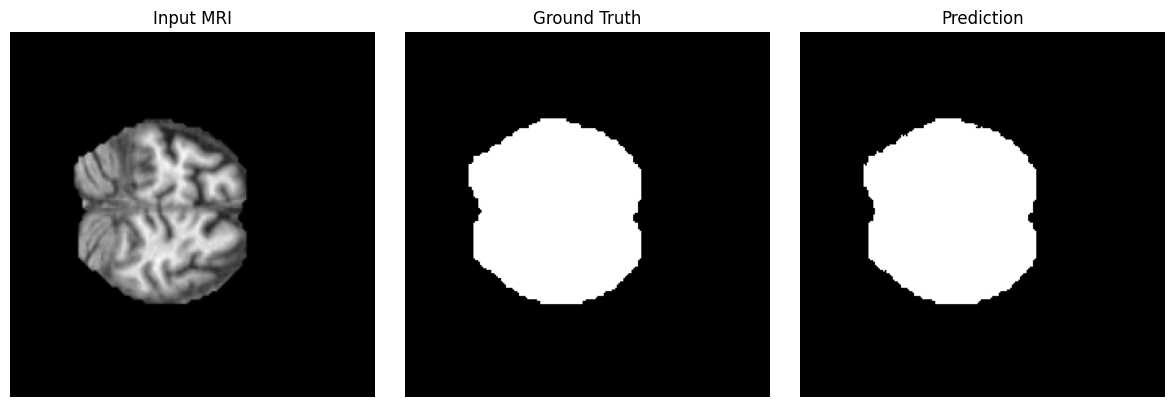

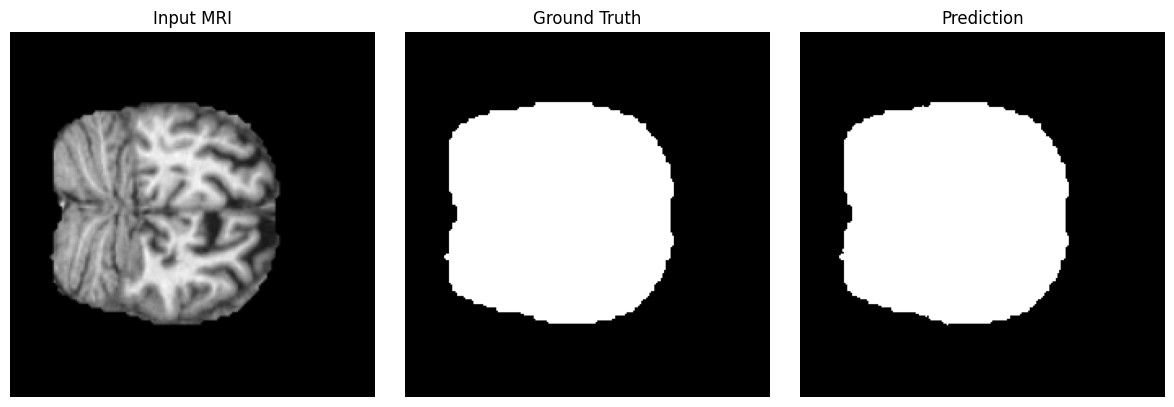

Prediction after epoch 50


Epoch 50: val_iou_score did not improve from 0.99763
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - dice_coefficient: 0.9979 - iou_score: 0.9959 - loss: 0.0028 - pixel_accuracy: 0.9999 - precision_smooth: 0.9965 - recall_smooth: 0.9993 - val_dice_coefficient: 0.9984 - val_iou_score: 0.9968 - val_loss: 0.0040 - val_pixel_accuracy: 0.9992 - val_precision_smooth: 0.9969 - val_recall_smooth: 0.9999 - learning_rate: 5.0000e-05
Epoch 51/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - dice_coefficient: 0.9992 - iou_score: 0.9984 - loss: 0.0014 - pixel_accuracy: 0.9998 - precision_smooth: 0.9989 - recall_smooth: 0.9995
Epoch 51: val_iou_score did not improve from 0.99763
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 425ms/step - dice_coefficient: 0.9992 - iou_score: 0.9984 - loss: 0.0014 - pixel_accuracy: 0.9998 - precision_smooth: 0.9989 - recall_smooth: 0.9995 - val_dice_coefficient: 0.9974 - val_iou_score: 0.9948 - val_loss: 0.0071 - val_pixel_accuracy: 0.9986 - val_precision

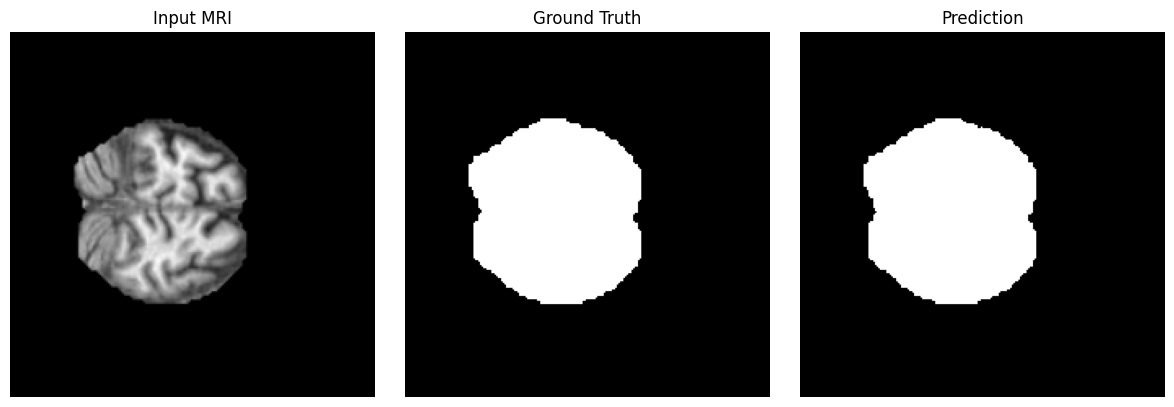

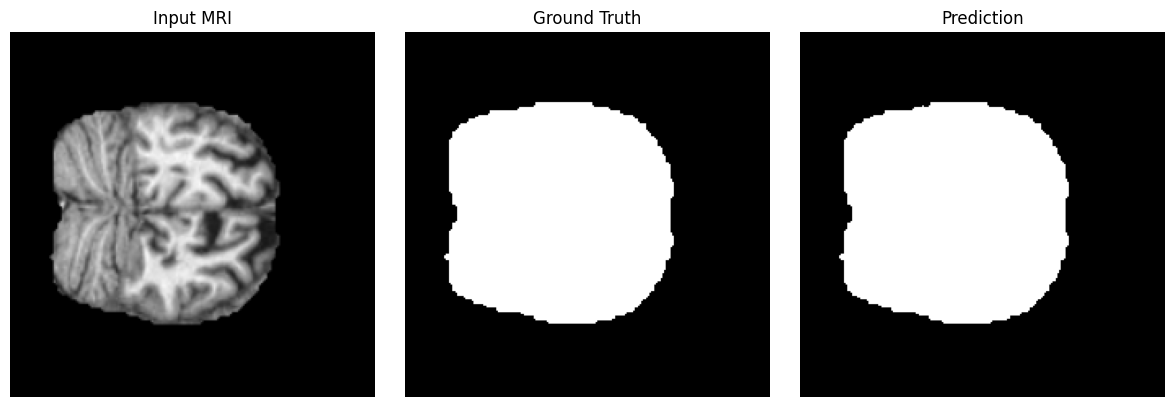

Prediction after epoch 60


Epoch 60: val_iou_score did not improve from 0.99830
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - dice_coefficient: 0.9987 - iou_score: 0.9973 - loss: 0.0018 - pixel_accuracy: 0.9999 - precision_smooth: 0.9977 - recall_smooth: 0.9996 - val_dice_coefficient: 0.9989 - val_iou_score: 0.9978 - val_loss: 0.0027 - val_pixel_accuracy: 0.9995 - val_precision_smooth: 0.9979 - val_recall_smooth: 1.0000 - learning_rate: 1.2500e-05
Epoch 61/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - dice_coefficient: 0.9995 - iou_score: 0.9990 - loss: 8.3748e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9993 - recall_smooth: 0.9997
Epoch 61: val_iou_score improved from 0.99830 to 0.99839, saving model to best_model_segnet.keras

Epoch 61: finished saving model to best_model_segnet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 150s 428ms/step - dice_coefficient: 0.9995 - iou_score: 0.9990 - loss: 8.6496e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9993 - recall_smooth: 0.9997 - val

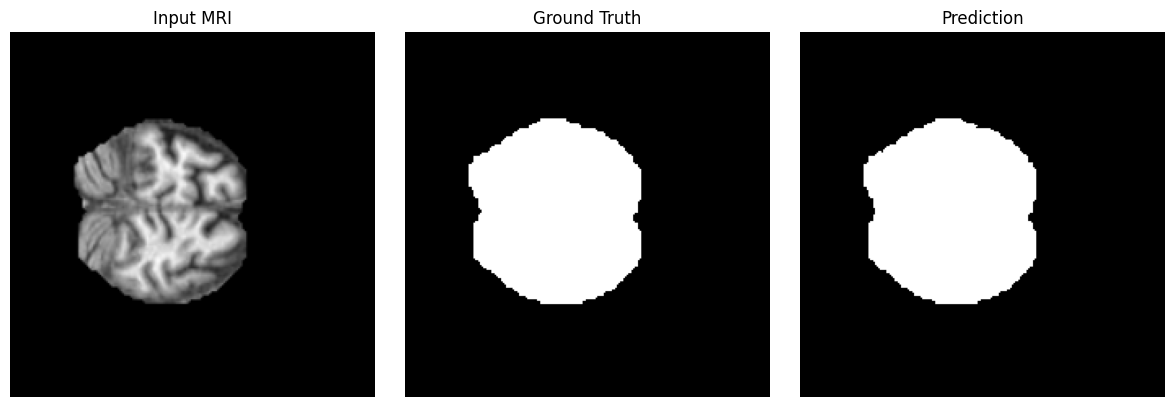

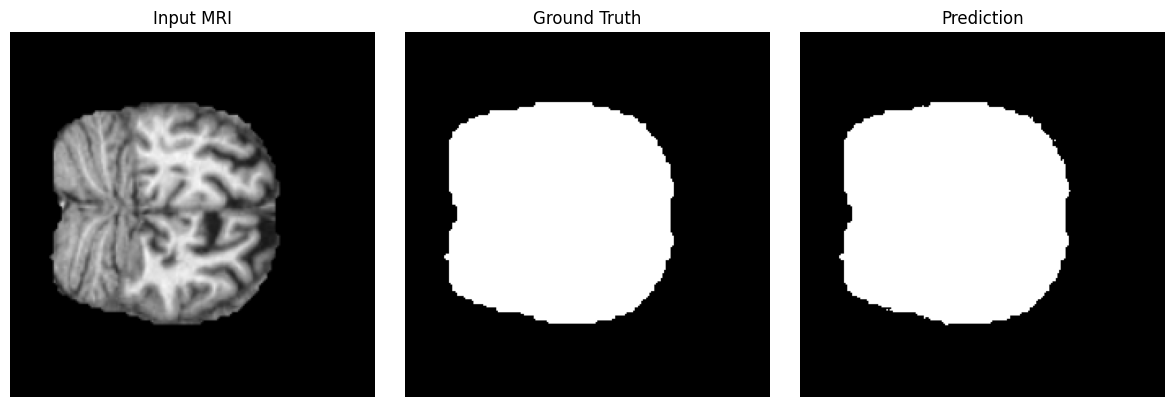

Prediction after epoch 70


Epoch 70: val_iou_score did not improve from 0.99874
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - dice_coefficient: 0.9989 - iou_score: 0.9978 - loss: 0.0015 - pixel_accuracy: 0.9999 - precision_smooth: 0.9984 - recall_smooth: 0.9994 - val_dice_coefficient: 0.9990 - val_iou_score: 0.9981 - val_loss: 0.0024 - val_pixel_accuracy: 0.9995 - val_precision_smooth: 0.9981 - val_recall_smooth: 1.0000 - learning_rate: 6.2500e-06
Epoch 71/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 6.8606e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9994 - recall_smooth: 0.9998
Epoch 71: val_iou_score did not improve from 0.99874
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 425ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 7.1136e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9994 - recall_smooth: 0.9997 - val_dice_coefficient: 0.9990 - val_iou_score: 0.9979 - val_loss: 0.0025 - val_pixel_accuracy: 0.9995 - val_p

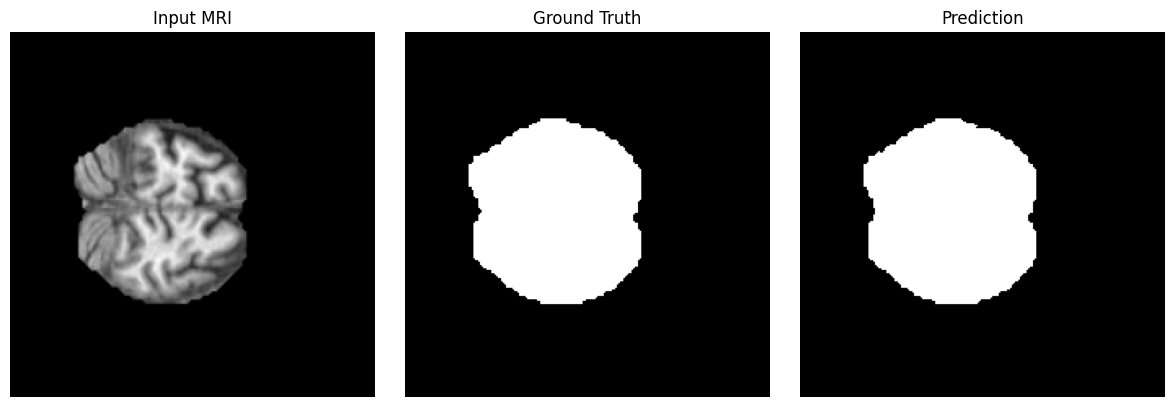

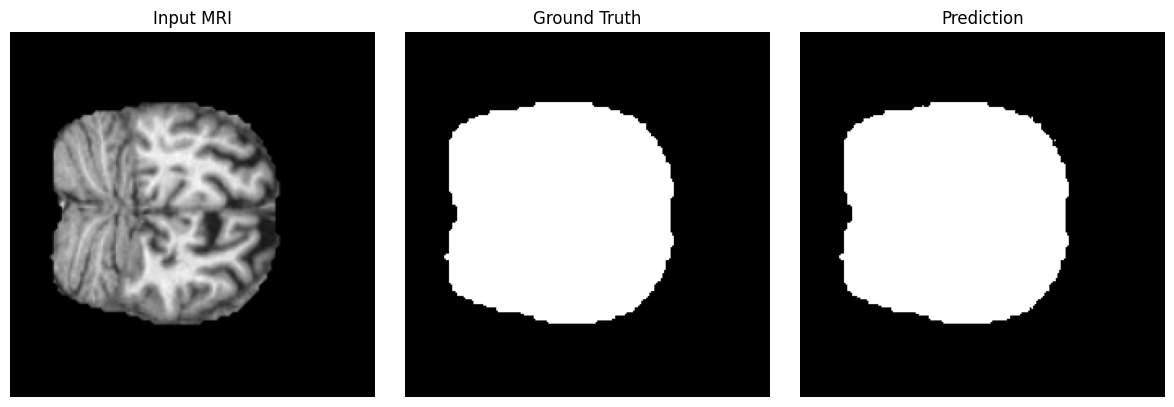

Prediction after epoch 80


Epoch 80: val_iou_score did not improve from 0.99901
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - dice_coefficient: 0.9990 - iou_score: 0.9981 - loss: 0.0013 - pixel_accuracy: 0.9999 - precision_smooth: 0.9985 - recall_smooth: 0.9996 - val_dice_coefficient: 0.9994 - val_iou_score: 0.9988 - val_loss: 0.0014 - val_pixel_accuracy: 0.9997 - val_precision_smooth: 0.9988 - val_recall_smooth: 1.0000 - learning_rate: 3.1250e-06
Epoch 81/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - dice_coefficient: 0.9996 - iou_score: 0.9993 - loss: 6.4151e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9995 - recall_smooth: 0.9998
Epoch 81: val_iou_score did not improve from 0.99901
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 425ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 6.7582e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9995 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9992 - val_iou_score: 0.9985 - val_loss: 0.0019 - val_pixel_accuracy: 0.9996 - val_p

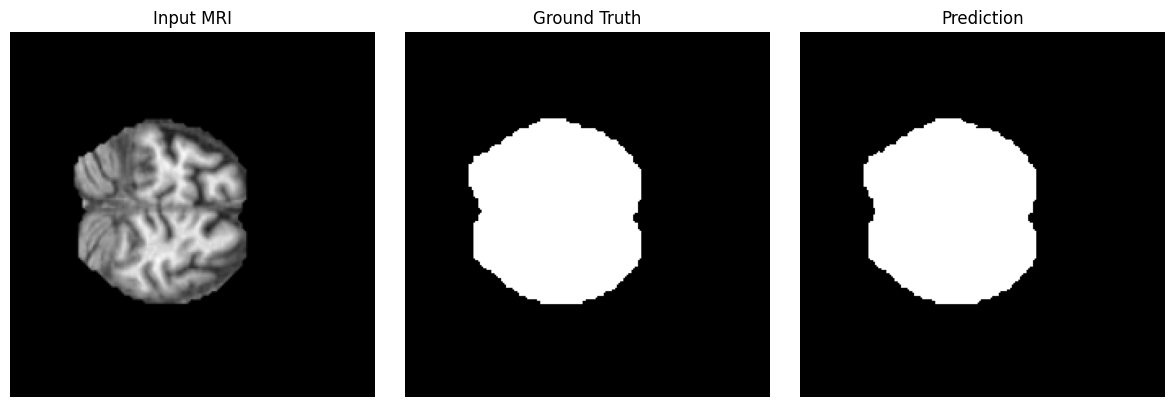

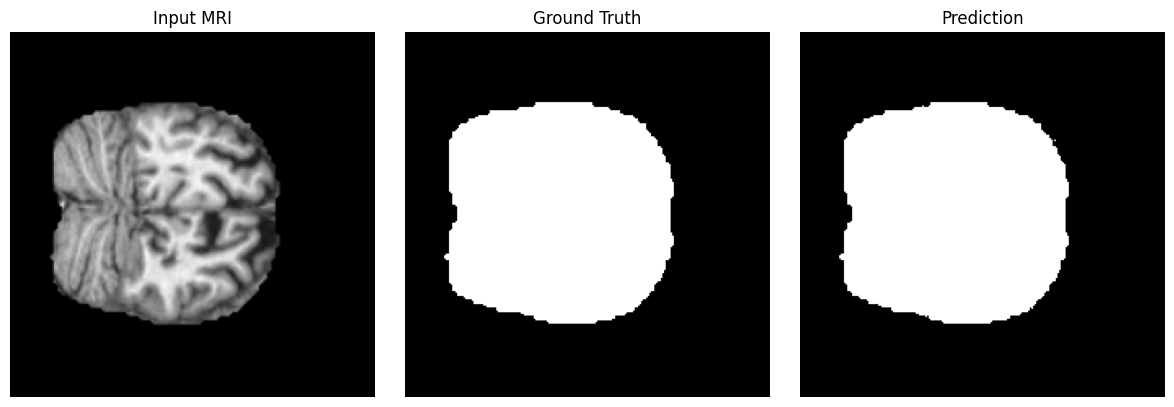

Prediction after epoch 90


Epoch 90: val_iou_score did not improve from 0.99901
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - dice_coefficient: 0.9991 - iou_score: 0.9981 - loss: 0.0013 - pixel_accuracy: 0.9999 - precision_smooth: 0.9986 - recall_smooth: 0.9995 - val_dice_coefficient: 0.9994 - val_iou_score: 0.9987 - val_loss: 0.0015 - val_pixel_accuracy: 0.9997 - val_precision_smooth: 0.9988 - val_recall_smooth: 1.0000 - learning_rate: 7.8125e-07
Epoch 91/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - dice_coefficient: 0.9997 - iou_score: 0.9993 - loss: 5.9384e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9995 - recall_smooth: 0.9998
Epoch 91: val_iou_score did not improve from 0.99901
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 424ms/step - dice_coefficient: 0.9996 - iou_score: 0.9993 - loss: 6.2550e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9995 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9994 - val_iou_score: 0.9988 - val_loss: 0.0014 - val_pixel_accuracy: 0.9997 - val_p

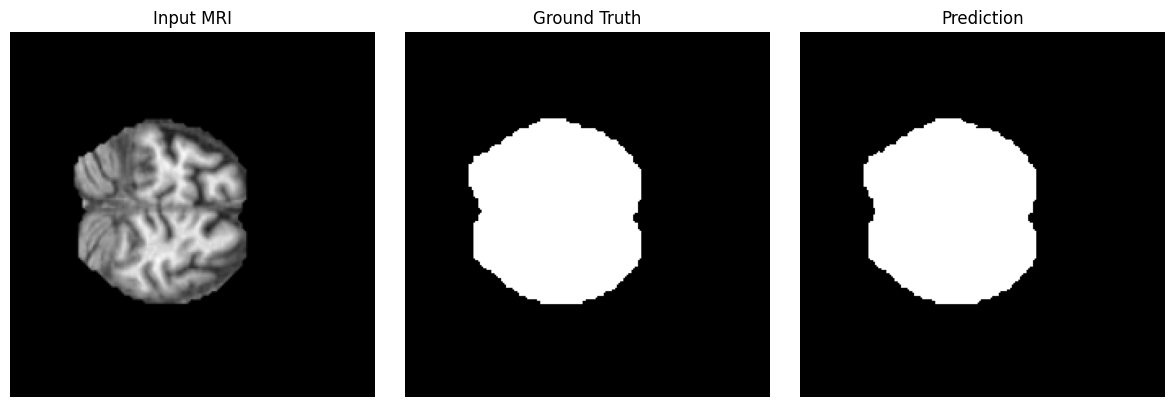

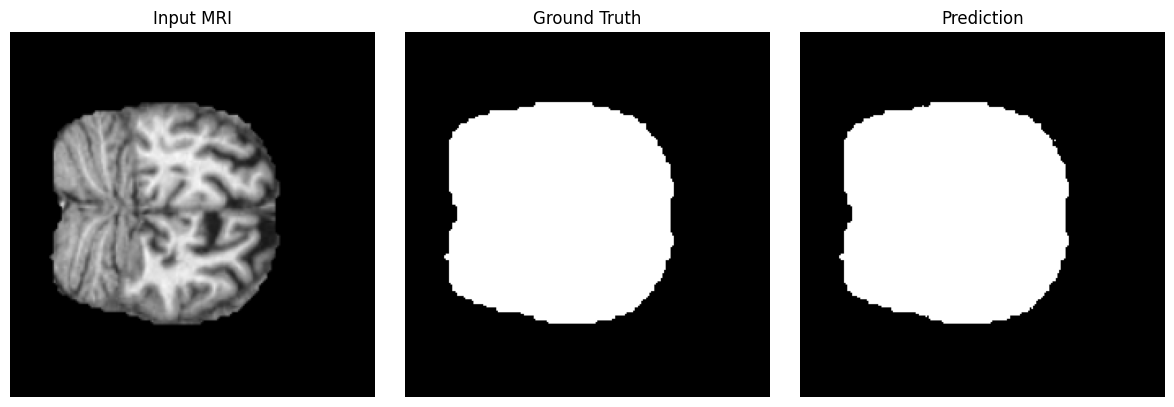

Prediction after epoch 100


Epoch 100: val_iou_score did not improve from 0.99901
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - dice_coefficient: 0.9992 - iou_score: 0.9983 - loss: 0.0011 - pixel_accuracy: 1.0000 - precision_smooth: 0.9986 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9994 - val_iou_score: 0.9988 - val_loss: 0.0014 - val_pixel_accuracy: 0.9997 - val_precision_smooth: 0.9988 - val_recall_smooth: 1.0000 - learning_rate: 1.9531e-07

Training time: 135.6 min


In [15]:
steps_per_epoch  = len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE
validation_steps = len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')

## 13. Training Graphs

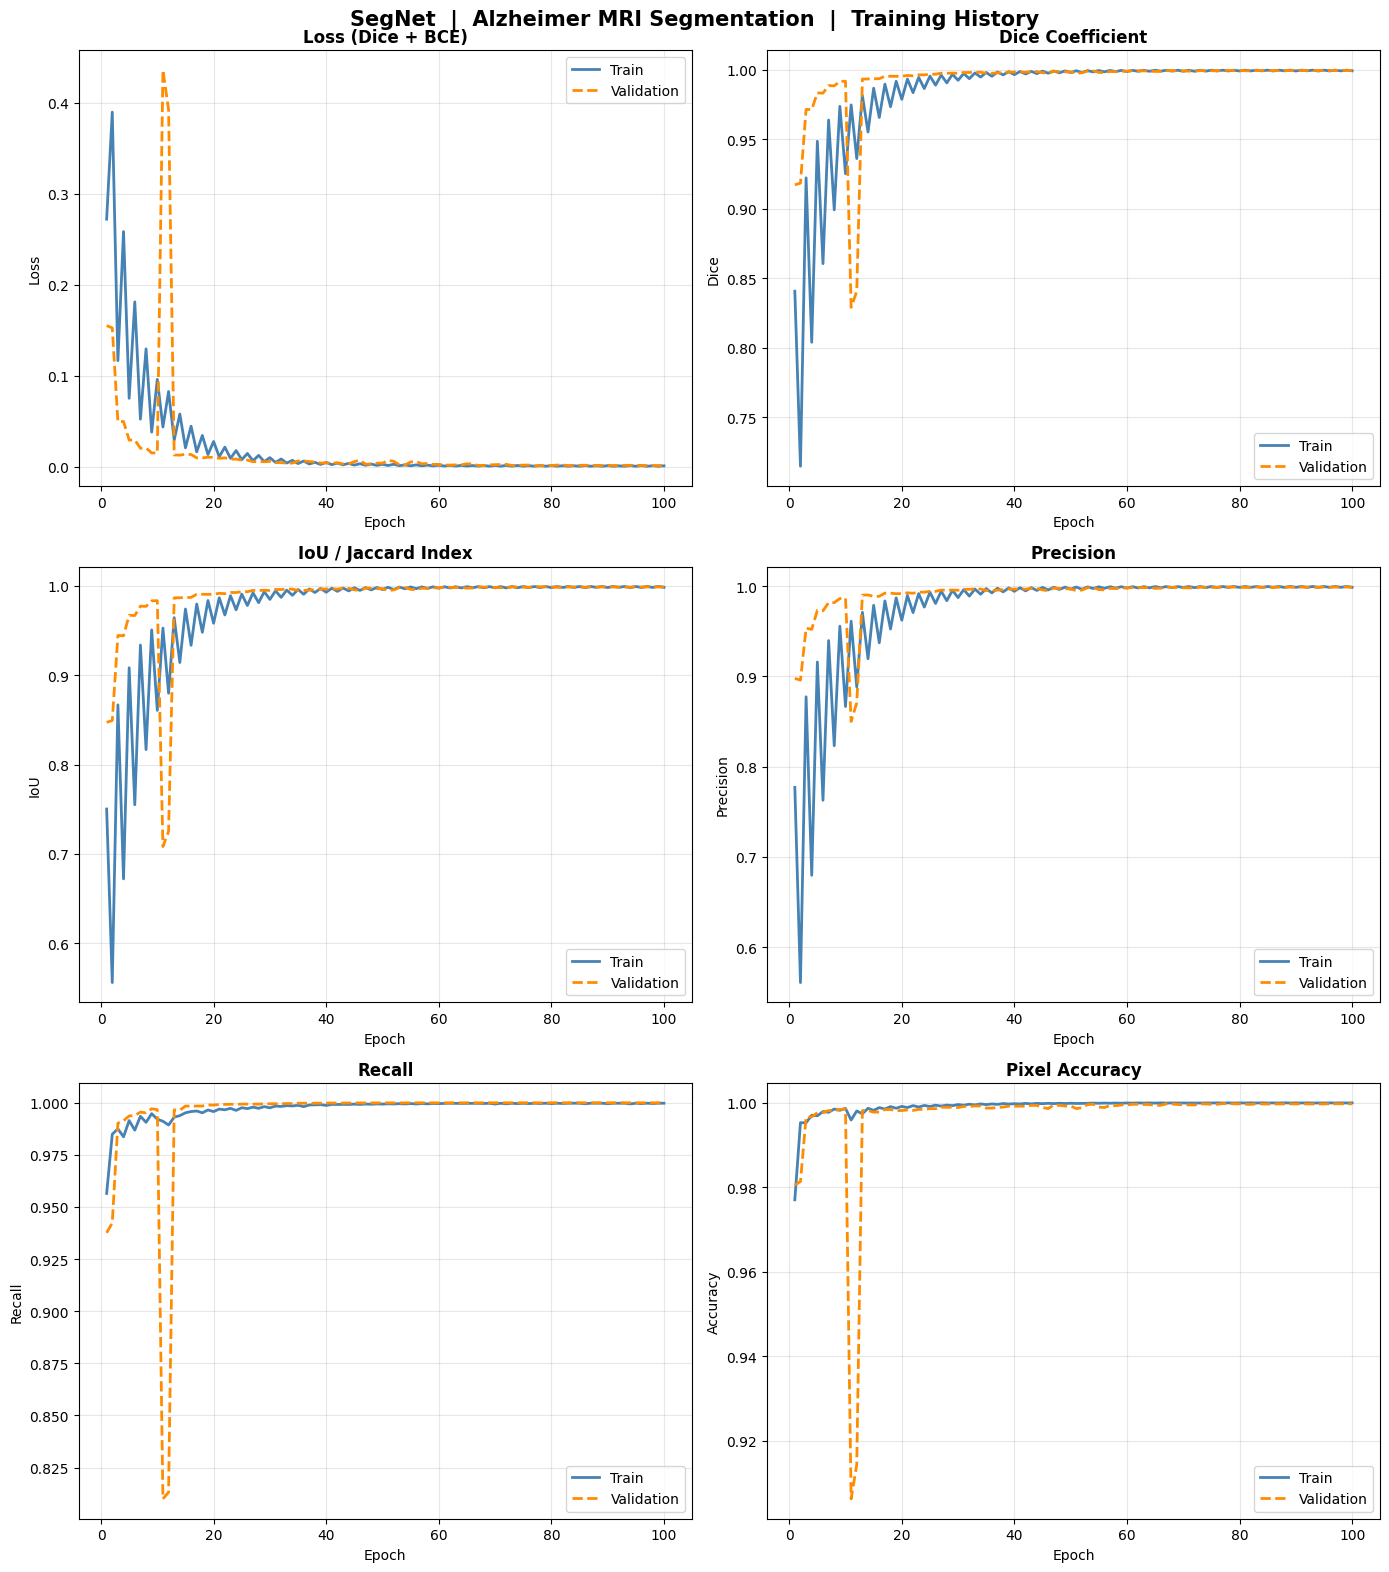

Plot saved → training_history_segnet.png


In [16]:
H = history.history

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('SegNet  |  Alzheimer MRI Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.98)

plot_specs = [
    ('loss',             'val_loss',             'Loss (Dice + BCE)',      'Loss',     'upper right'),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient',       'Dice',     'lower right'),
    ('iou_score',        'val_iou_score',        'IoU / Jaccard Index',    'IoU',      'lower right'),
    ('precision_smooth', 'val_precision_smooth', 'Precision',              'Precision','lower right'),
    ('recall_smooth',    'val_recall_smooth',    'Recall',                 'Recall',   'lower right'),
    ('pixel_accuracy',   'val_pixel_accuracy',   'Pixel Accuracy',         'Accuracy', 'lower right'),
]

for ax, (train_key, val_key, title, ylabel, loc) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train',      color='steelblue',   linewidth=2)
    ax.plot(epochs_range, H[val_key],   label='Validation', color='darkorange',  linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(loc=loc, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_segnet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → training_history_segnet.png')

## 14. Best & Average Metrics Table

In [17]:
metric_spec = [
    ('Loss',           'loss',             'min'),
    ('Dice',           'dice_coefficient', 'max'),
    ('IoU (Jaccard)',  'iou_score',        'max'),
    ('Precision',      'precision_smooth', 'max'),
    ('Recall',         'recall_smooth',    'max'),
    ('Pixel Accuracy', 'pixel_accuracy',   'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key],          dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({
        'Metric':     disp,
        'Train Best': pick(tr), 'Train Avg': tr.mean(),
        'Val Best':   pick(va), 'Val Avg':   va.mean(),
    })

def f1_curve(p, r):
    p = np.asarray(p, dtype=np.float64); r = np.asarray(r, dtype=np.float64)
    return 2.0 * p * r / (p + r + 1e-7)

tr_f1 = f1_curve(H['precision_smooth'],     H['recall_smooth'])
va_f1 = f1_curve(H['val_precision_smooth'], H['val_recall_smooth'])
rows.append({'Metric': 'F1-Score',
             'Train Best': tr_f1.max(), 'Train Avg': tr_f1.mean(),
             'Val Best':   va_f1.max(), 'Val Avg':   va_f1.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  SegNet  |  OASIS disc1+disc2')
print('=' * 68)
print(report.to_string())
print('=' * 68)

best_epoch_iou  = int(np.argmax(H['val_iou_score']))  + 1
best_epoch_dice = int(np.argmax(H['val_dice_coefficient'])) + 1
print(f'\nBest Val IoU : {max(H["val_iou_score"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val Dice: {max(H["val_dice_coefficient"]):.4f}  (epoch {best_epoch_dice})')

# Overfitting check — gap between train and val at final epoch
final_gap_iou  = H['val_iou_score'][-1]  - H['iou_score'][-1]
final_gap_dice = H['val_dice_coefficient'][-1] - H['dice_coefficient'][-1]
print(f'\nFinal-epoch Val-Train gap → IoU: {final_gap_iou:+.4f}, Dice: {final_gap_dice:+.4f}')
print('(Large positive gap can indicate train metrics still catching up;')
print(' large negative gap with val dropping while train keeps rising = overfitting.)')

report

   BEST & AVERAGE METRICS  —  SegNet  |  OASIS disc1+disc2
                Train Best  Train Avg  Val Best  Val Avg
Metric                                                  
Loss                0.0006     0.0223    0.0011   0.0173
Dice                0.9996     0.9841    0.9995   0.9921
IoU (Jaccard)       0.9993     0.9721    0.9990   0.9855
Precision           0.9995     0.9742    0.9990   0.9901
Recall              0.9998     0.9974    1.0000   0.9943
Pixel Accuracy      1.0000     0.9992    0.9998   0.9970
F1-Score            0.9996     0.9844    0.9995   0.9921

Best Val IoU : 0.9990  (epoch 77)
Best Val Dice: 0.9995  (epoch 77)

Final-epoch Val-Train gap → IoU: +0.0005, Dice: +0.0002
(Large positive gap can indicate train metrics still catching up;
 large negative gap with val dropping while train keeps rising = overfitting.)


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.0006,0.0223,0.0011,0.0173
Dice,0.9996,0.9841,0.9995,0.9921
IoU (Jaccard),0.9993,0.9721,0.9990,0.9855
Precision,0.9995,0.9742,0.9990,0.9901
Recall,0.9998,0.9974,1.0000,0.9943
Pixel Accuracy,1.0000,0.9992,0.9998,0.9970
F1-Score,0.9996,0.9844,0.9995,0.9921


## 15. Load Best Model & Final Evaluation

In [18]:
best_model = tf.keras.models.load_model(
    'best_model_segnet.keras',
    custom_objects={
    'combined_loss':   combined_loss,
    'dice_coefficient': dice_coefficient,
    'iou_score':        iou_score,
    'precision_smooth': precision_smooth,
    'recall_smooth':    recall_smooth,
    'pixel_accuracy':   pixel_accuracy,
    'MaxPoolingWithIndices': MaxPoolingWithIndices,
    'MaxUnpooling':          MaxUnpooling,
}
)
print('Best model loaded ✓')
best_model.summary()

Best model loaded ✓


Model: "SegNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c1 (Conv2D)    │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 224, 224,  │        256 │ enc1_c1[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act1           │ (None, 224, 224,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c2 (Conv2D)    │ (None, 224, 224,  │     36,928 │ enc1_act1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 224, 224,  │        256 │ enc1_c2[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act2           │ (None, 224, 224,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling_with_i… │ [(None, 7, 7,     │          0 │ enc1_act2[0][0],  │
│ (MaxPoolingWithInd… │ 512), (None, 7,   │            │ enc2_act2[0][0],  │
│                     │ 7, 512)]          │            │ enc3_act3[0][0],  │
│                     │                   │            │ enc4_act3[0][0],  │
│                     │                   │            │ enc5_act3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c1 (Conv2D)    │ (None, 112, 112,  │     73,856 │ max_pooling_with… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 112, 112,  │        512 │ enc2_c1[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_act1           │ (None, 112, 112,  │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c2 (Conv2D)    │ (None, 112, 112,  │    147,584 │ enc2_act1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 112, 112,  │        512 │ enc2_c2[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_act2           │ (None, 112, 112,  │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c1 (Conv2D)    │ (None, 56, 56,    │    295,168 │ max_pooling_with… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 56, 56,    │      1,024 │ enc3_c1[0][0]   

 Total params: 74,844,421 (285.51 MB)

 Trainable params: 24,943,361 (95.15 MB)

 Non-trainable params: 14,336 (56.00 KB)

 Optimizer params: 49,886,724 (190.30 MB)

In [19]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict    = dict(zip(best_model.metrics_names, test_results))

label_map = {
    'loss': 'Loss', 'dice_coefficient': 'Dice', 'iou_score': 'IoU (Jaccard)',
    'precision_smooth': 'Precision', 'recall_smooth': 'Recall', 'pixel_accuracy': 'Pixel Accuracy'
}

P = test_dict.get('precision_smooth', 0)
R = test_dict.get('recall_smooth',    0)
f1 = 2 * P * R / (P + R + 1e-7)

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (SegNet | OASIS disc1+disc2)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {label_map.get(k, k):20s}: {v:.4f}')
print(f'  {"F1-Score":20s}: {f1:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model':      'SegNet (OASIS disc1+disc2)',
    'IoU':        round(test_dict.get('iou_score', float('nan')), 4),
    'Dice':       round(test_dict.get('dice_coefficient', float('nan')), 4),
    'Precision':  round(P, 4),
    'Recall':     round(R, 4),
    'Accuracy':   round(test_dict.get('pixel_accuracy', float('nan')), 4),
    'F1':         round(f1, 4),
}]).set_index('Model')
final_df

Evaluating best model on held-out test set...

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - dice_coefficient: 0.9995 - iou_score: 0.9990 - loss: 0.0011 - pixel_accuracy: 0.9998 - precision_smooth: 0.9990 - recall_smooth: 1.0000

  FINAL TEST-SET METRICS  (SegNet | OASIS disc1+disc2)
  Loss                : 0.0011
  compile_metrics     : 0.9995
  F1-Score            : 0.0000


,IoU,Dice,Precision,Recall,Accuracy,F1
Model,,,,,,
SegNet (OASIS disc1+disc2),NaN,NaN,0,0,NaN,0.0


## 16. Test Predictions Visualization

Test set predictions:


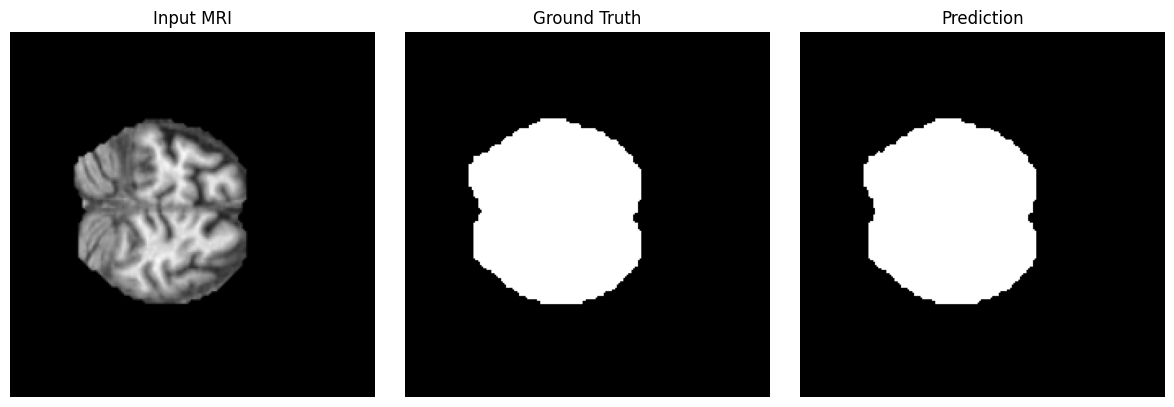

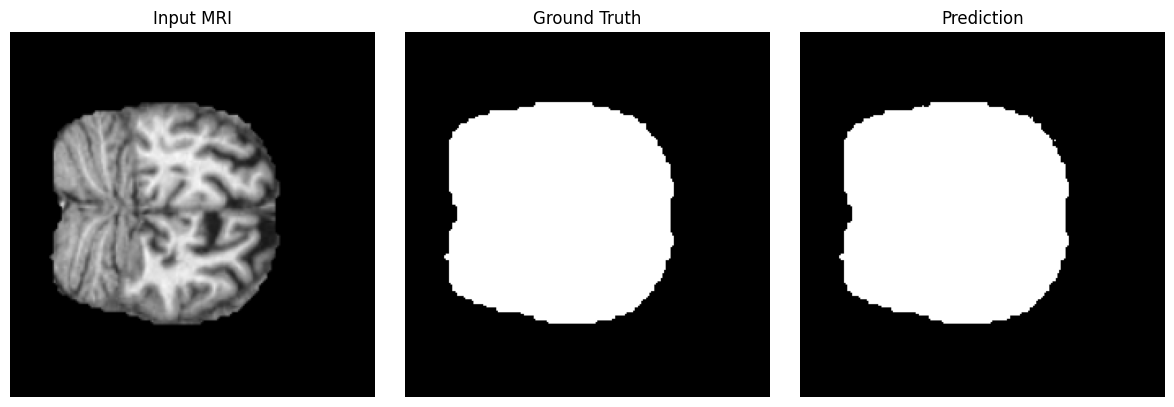

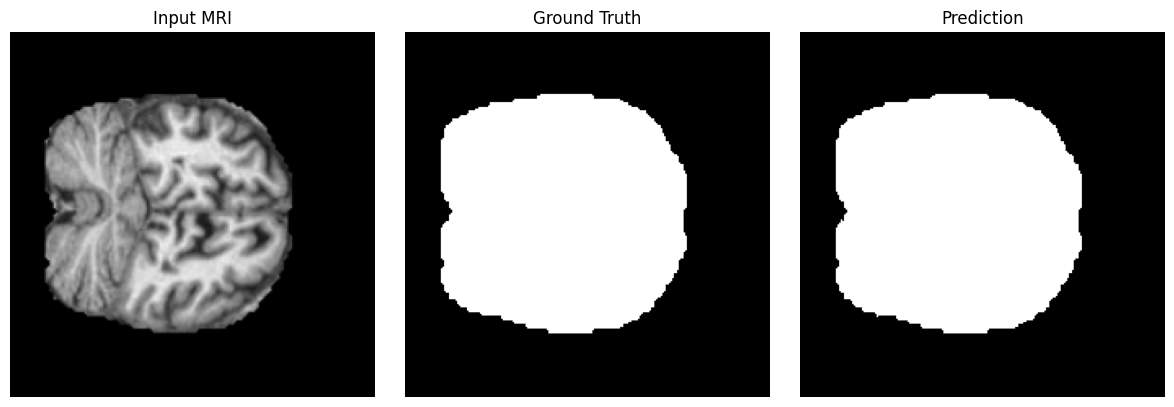

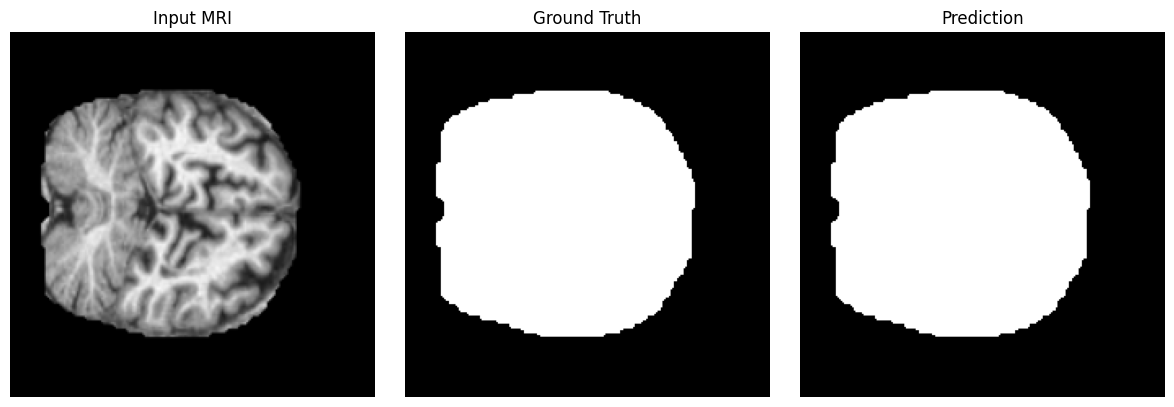

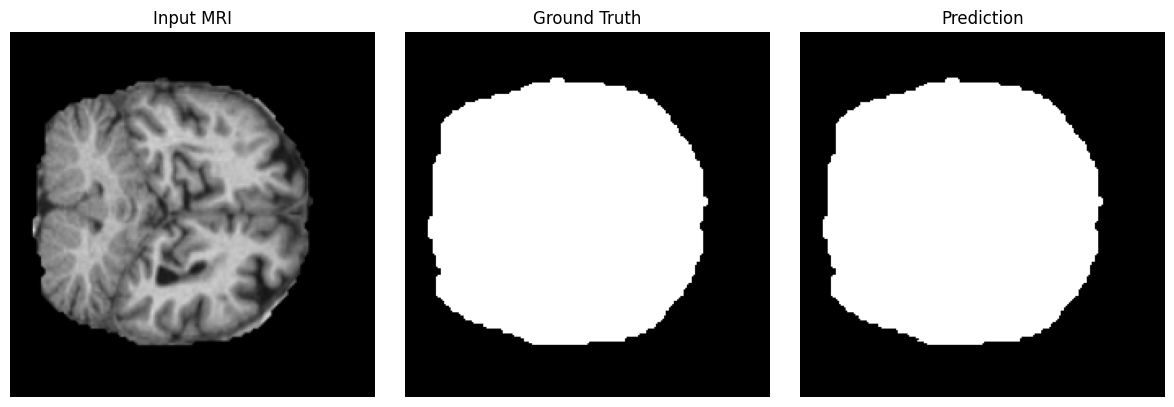

In [20]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Detailed Prediction Grid

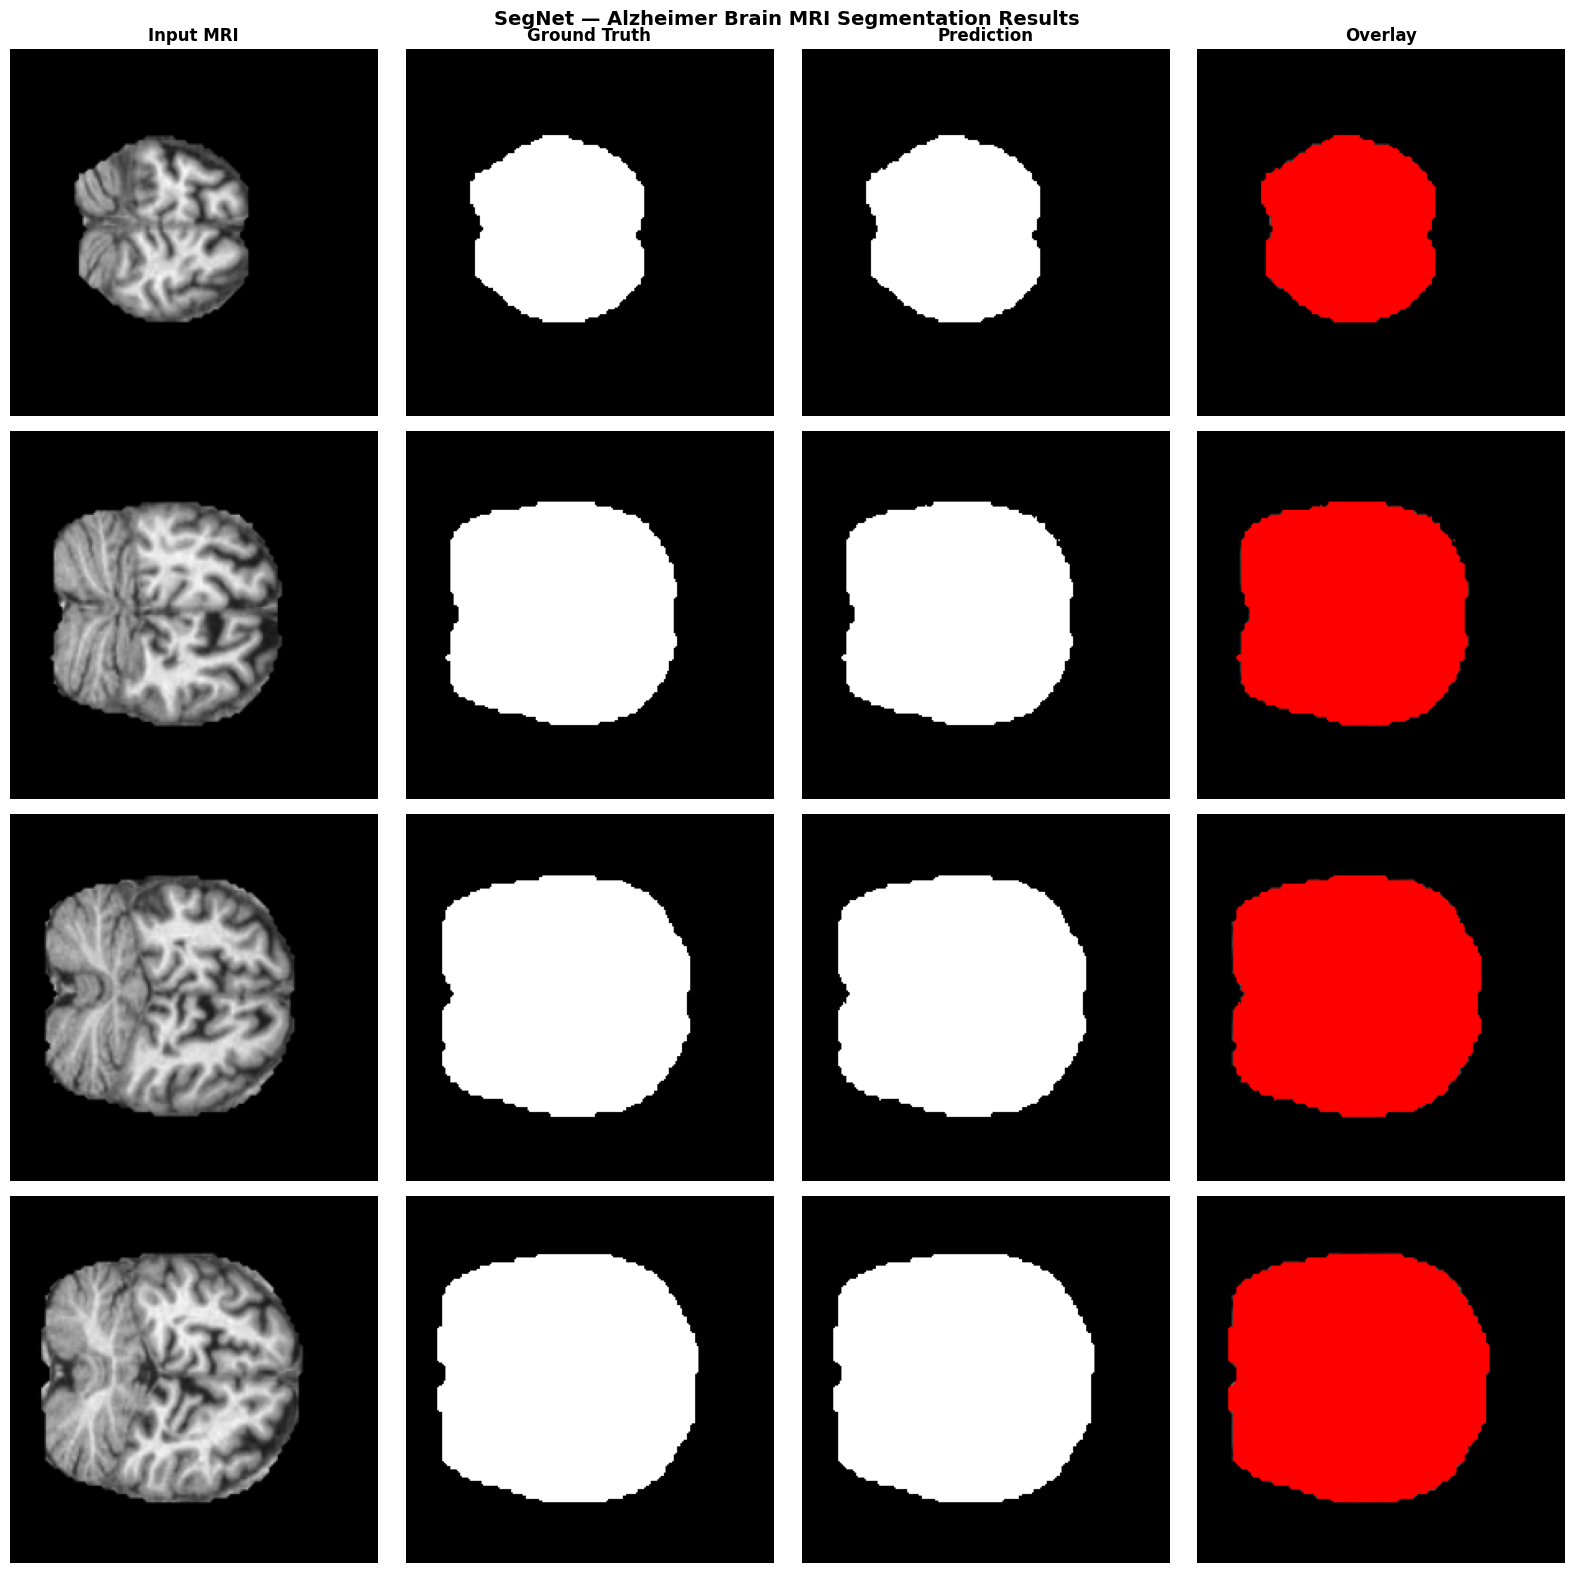

Grid saved → prediction_grid_segnet.png


In [21]:
def prediction_grid(dataset, best_model, n_rows=4):
    for imgs, masks in dataset.take(1):
        preds = best_model.predict(imgs[:n_rows], verbose=0)

        fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
        col_titles = ['Input MRI', 'Ground Truth', 'Prediction', 'Overlay']
        for col, t in enumerate(col_titles):
            axes[0, col].set_title(t, fontsize=12, fontweight='bold')

        for row in range(n_rows):
            img   = imgs[row].numpy()
            gt    = masks[row].numpy()[..., 0]
            pred  = create_mask(preds[row]).numpy()[..., 0]

            ov = (img * 255).astype(np.uint8)
            ov[pred > 0.5, 0] = 255
            ov[pred > 0.5, 1] = 0
            ov[pred > 0.5, 2] = 0

            inter = np.sum(gt * pred)
            union = np.sum(gt) + np.sum(pred) - inter
            sample_iou = (inter + 1) / (union + 1)

            axes[row, 0].imshow(img)
            axes[row, 1].imshow(gt,   cmap='gray')
            axes[row, 2].imshow(pred, cmap='gray')
            axes[row, 2].set_xlabel(f'IoU: {sample_iou:.3f}', fontsize=10, color='green')
            axes[row, 3].imshow(ov)

            for col in range(4):
                axes[row, col].axis('off')

        plt.suptitle('SegNet — Alzheimer Brain MRI Segmentation Results',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('prediction_grid_segnet.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Grid saved → prediction_grid_segnet.png')


prediction_grid(test_dataset, best_model, n_rows=4)

## 18. IoU Distribution Plot

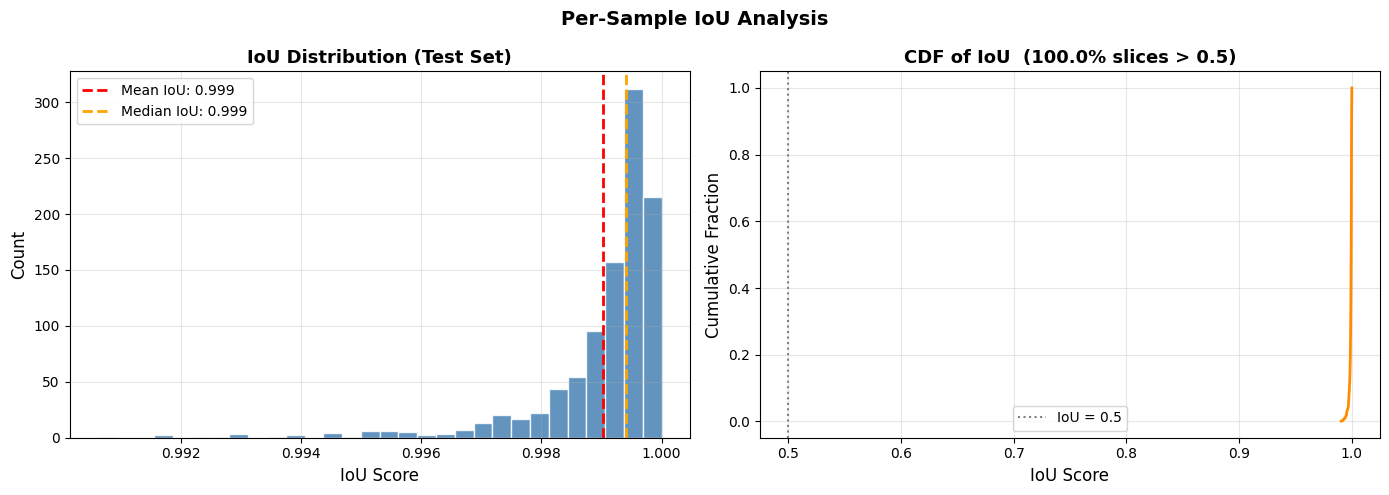


IoU Stats — Mean: 0.9990  |  Std: 0.0011
             Min : 0.9906  |  Max: 1.0000
% slices IoU > 0.5 : 100.0%


In [22]:
iou_scores = []

for imgs, masks in test_dataset:
    preds = best_model.predict(imgs, verbose=0)
    for i in range(len(imgs)):
        gt   = masks[i].numpy()[..., 0]
        pred = (preds[i][..., 0] > 0.5).astype(float)
        inter = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - inter
        iou_scores.append((inter + 1) / (union + 1))

iou_arr = np.array(iou_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(iou_arr, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(iou_arr.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean IoU: {iou_arr.mean():.3f}')
axes[0].axvline(np.median(iou_arr), color='orange', linestyle='--', linewidth=2,
                label=f'Median IoU: {np.median(iou_arr):.3f}')
axes[0].set_xlabel('IoU Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('IoU Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sorted_iou = np.sort(iou_arr)
cdf = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
axes[1].plot(sorted_iou, cdf, color='darkorange', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle=':', label='IoU = 0.5')
pct_above_50 = np.mean(iou_arr > 0.5) * 100
axes[1].set_xlabel('IoU Score', fontsize=12)
axes[1].set_ylabel('Cumulative Fraction', fontsize=12)
axes[1].set_title(f'CDF of IoU  ({pct_above_50:.1f}% slices > 0.5)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Per-Sample IoU Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iou_distribution_segnet.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nIoU Stats — Mean: {iou_arr.mean():.4f}  |  Std: {iou_arr.std():.4f}')
print(f'             Min : {iou_arr.min():.4f}  |  Max: {iou_arr.max():.4f}')
print(f'% slices IoU > 0.5 : {pct_above_50:.1f}%')

## 19. Save Final Model

In [23]:
best_model.save('alzheimer_segnet_final.keras')
print('Model saved → alzheimer_segnet_final.keras')

Model saved → alzheimer_segnet_final.keras
